In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns


Taille dataset : (20169, 13)
  dataloadingdate  Jour  Mois  NumeroSemaine  Trimestre  JourSemaineNum  \
0      01/07/2025     1     7             27          3               1   
1      01/07/2025     1     7             27          3               1   
2      01/07/2025     1     7             27          3               1   
3      01/07/2025     1     7             27          3               1   
4      01/07/2025     1     7             27          3               1   

  JourSemaine          ISIN                Libellé  Nombre de Titres  Montant  \
0     Tuesday  TN0008000739  BTA 7,4% Fevrier 2030            1459.0    1.500   
1     Tuesday  TN0008000739  BTA 7,4% Fevrier 2030             291.0    0.300   
2     Tuesday  TNMCPXLL1EE2  EMP NAT 2023 T4 CB TV           50000.0    5.000   
3     Tuesday  TNMCPXLL1EE2  EMP NAT 2023 T4 CB TV           10000.0    1.000   
4     Tuesday  TN0008000606    BTA 6,7% Avril 2028            5660.0    5.742   

   Echéance  Taux  
0      62.0  

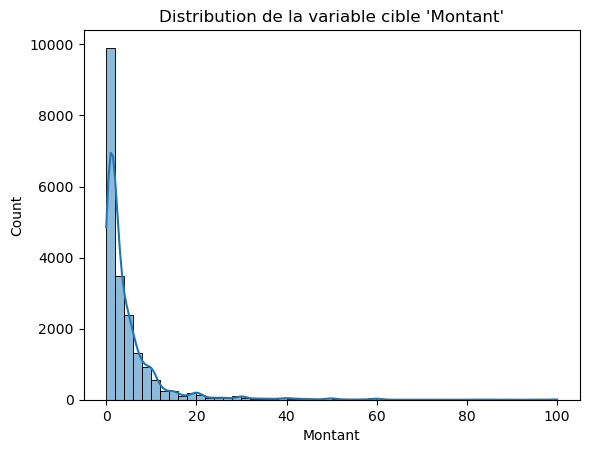

In [3]:
df = pd.read_csv(r"C:\Users\zizou\OneDrive\Desktop\stage 3ème\day 2\csvfiles\dataframefinale.csv",sep=";")
print(f"Taille dataset : {df.shape}")
print(df.head())

# Statistiques de base
print(df.describe())

# Visualisation distribution target 'Montant'
sns.histplot(df['Montant'], bins=50, kde=True)
plt.title("Distribution de la variable cible 'Montant'")
plt.show()


In [4]:
# Attention: la target doit être strictement positive pour le log
if (df['Montant'] <= 0).any():
    print("Des valeurs <= 0 dans Montant, log-transform non possible")
    target = 'Montant'
else:
    df['Montant_log'] = np.log(df['Montant'])
    target = 'Montant_log'
    print("Log-transform appliqué à la target")


Log-transform appliqué à la target


In [5]:
features = df.select_dtypes(include=[np.number]).columns.tolist()
features.remove(target)  # Retirer la target de la liste

X = df[features]
y = df[target]

print(f"Nombre de features : {len(features)}")
print(f"Features : {features}")
print(f"Nombre d'exemples : {len(df)}")


Nombre de features : 9
Features : ['Jour', 'Mois', 'NumeroSemaine', 'Trimestre', 'JourSemaineNum', 'Nombre de Titres', 'Montant', 'Echéance', 'Taux']
Nombre d'exemples : 20169


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Train size: {X_train.shape[0]} samples")
print(f"Test size: {X_test.shape[0]} samples")


Train size: 16135 samples
Test size: 4034 samples


In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [8]:
k = min(5, X_train_scaled.shape[1])

selector = SelectKBest(score_func=f_regression, k=k)
X_train_sel = selector.fit_transform(X_train_scaled, y_train)
X_test_sel = selector.transform(X_test_scaled)

selected_features = [features[i] for i in selector.get_support(indices=True)]
print(f"Features sélectionnées (k={k}): {selected_features}")


Features sélectionnées (k=5): ['Jour', 'JourSemaineNum', 'Nombre de Titres', 'Montant', 'Taux']


In [9]:
rf = RandomForestRegressor(random_state=42)


In [10]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


In [11]:
rf.fit(X_train_sel, y_train)
preds = rf.predict(X_test_sel)
rmse_brut = rmse(y_test, preds)
print(f"RMSE brut (train/test) : {rmse_brut:.4f}")


RMSE brut (train/test) : 0.0096


In [12]:
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}


In [13]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=kf,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train_sel, y_train)

print(f"Meilleurs paramètres : {random_search.best_params_}")



Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\zizou\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
20 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
19 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\zizou\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\zizou\anaconda3\Lib\site-packages\sklearn\base.py", line 1466, in wrapper
    estimator._validate_params()
  File "c:\Users\zizou\anaconda3\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "c:\Users\zizou\anaconda3\Lib\site-packages

Meilleurs paramètres : {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}


In [14]:
best_rf = random_search.best_estimator_

scores = cross_val_score(best_rf, X_train_sel, y_train,
                         cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
rmse_cv = np.sqrt(-scores).mean()

print(f"RMSE cross-validation (train) : {rmse_cv:.4f}")


RMSE cross-validation (train) : 0.0291


In [15]:
preds_test = best_rf.predict(X_test_sel)
rmse_test = rmse(y_test, preds_test)
print(f"RMSE sur jeu test (meilleur modèle) : {rmse_test:.4f}")


RMSE sur jeu test (meilleur modèle) : 0.0311


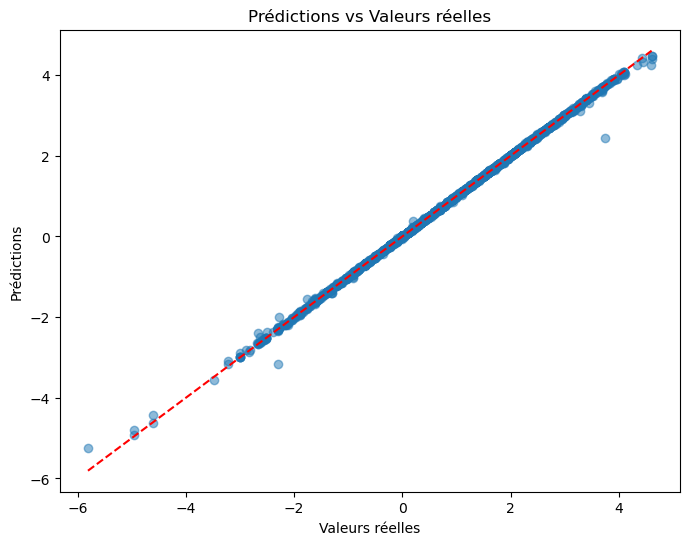

In [16]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, preds_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions")
plt.title("Prédictions vs Valeurs réelles")
plt.show()


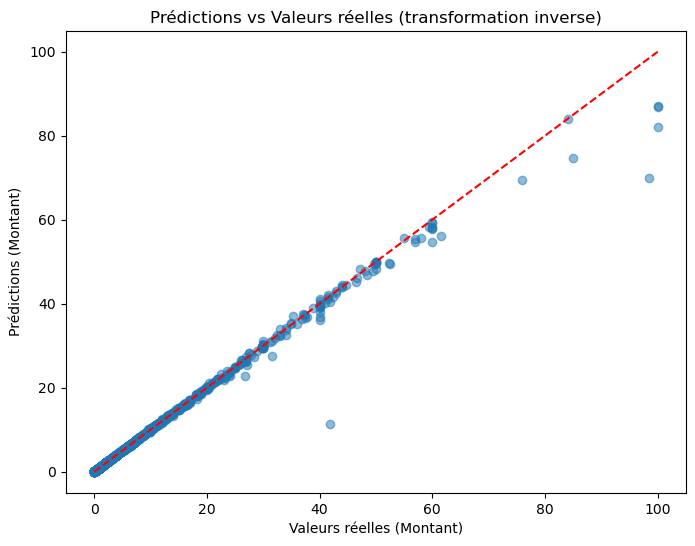

In [17]:
if target == 'Montant_log':
    y_test_real = np.exp(y_test)
    preds_real = np.exp(preds_test)

    plt.figure(figsize=(8,6))
    plt.scatter(y_test_real, preds_real, alpha=0.5)
    plt.plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 'r--')
    plt.xlabel("Valeurs réelles (Montant)")
    plt.ylabel("Prédictions (Montant)")
    plt.title("Prédictions vs Valeurs réelles (transformation inverse)")
    plt.show()


In [18]:
print("=== Résumé ===")
print(f"RMSE brut: {rmse_brut:.4f}")
print(f"RMSE cross-validation (train): {rmse_cv:.4f}")
print(f"RMSE test set (meilleur modèle): {rmse_test:.4f}")
print(f"Meilleurs paramètres: {random_search.best_params_}")


=== Résumé ===
RMSE brut: 0.0096
RMSE cross-validation (train): 0.0291
RMSE test set (meilleur modèle): 0.0311
Meilleurs paramètres: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
